In [1]:
import os
import scipy.io
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys
import subprocess
import pandas as pd
import numpy as np

# 1. Point to your current directory (since your notebook is in 'data')
data_dir = "../../data" 

# 2. Read the descriptive names from dataset_names.txt
names_file_path = os.path.join(data_dir, "dataset_names.txt")

with open(names_file_path, "r") as f:
    dataset_names = [line.strip() for line in f.readlines() if line.strip()]

print(f"Loaded {len(dataset_names)} dataset names from text file.")

# 3. Loop through folders '1' to '62' and load the nested 'data.mat' files
all_datasets = {}

for i, name in enumerate(dataset_names):
    file_number = i + 1
    
    # Path format: ./1/data.mat, ./2/data.mat, etc.
    file_path = os.path.join(data_dir, str(file_number), "data.mat")
    
    if os.path.exists(file_path):
        try:
            # Load the MATLAB format file
            mat_data = scipy.io.loadmat(file_path)
            
            # Filter out MATLAB's internal metadata headers
            clean_data = {k: v for k, v in mat_data.items() if not k.startswith('__')}
            
            # Map it to its descriptive text name
            all_datasets[name] = clean_data
        except Exception as e:
            print(f"Could not load file from folder {file_number} ({name}): {e}")
    else:
        print(f"Warning: File '{file_path}' not found for dataset '{name}'")

print(f"\nSuccessfully loaded {len(all_datasets)} datasets into memory!")

Loaded 62 dataset names from text file.

Successfully loaded 62 datasets into memory!


In [13]:

forest_data = all_datasets["'the-forest-cover-dataset'"]

# Extract features (X) and target (y)
X = forest_data['X']
y = forest_data['y'].ravel()

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

Features shape: (38501, 54)
Target shape: (38501,)


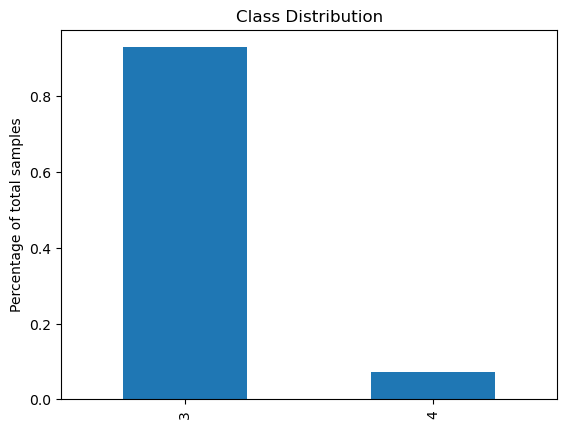

In [17]:
# Check label distribution
pd.Series(y).value_counts(normalize=True).plot(kind='bar', title='Class Distribution')
plt.ylabel('Percentage of total samples')
plt.show()

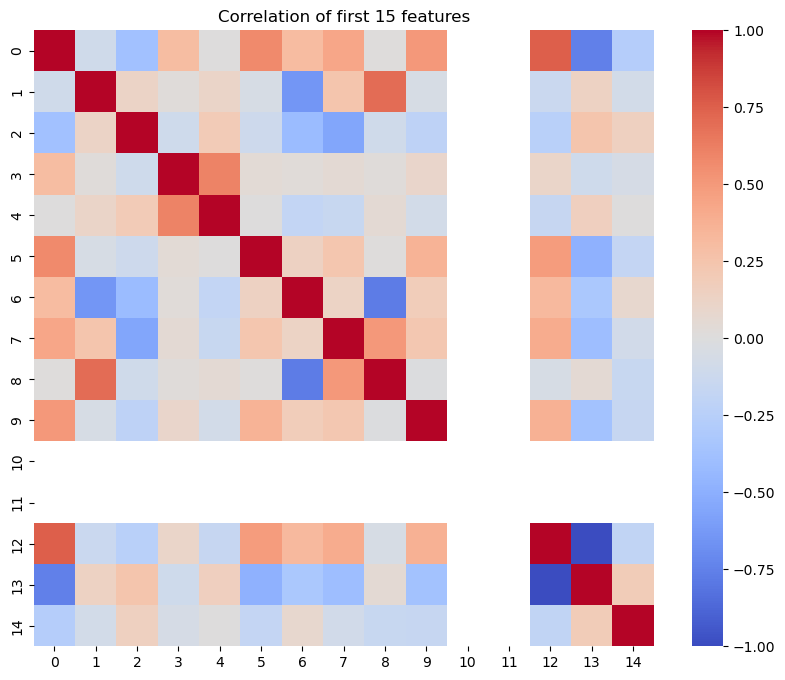

In [18]:
# Select a subset of features (e.g., first 15) to keep the plot readable
df_features = pd.DataFrame(X[:, :15])
plt.figure(figsize=(10, 8))
sns.heatmap(df_features.corr(), annot=False, cmap='coolwarm')
plt.title('Correlation of first 15 features')
plt.show()

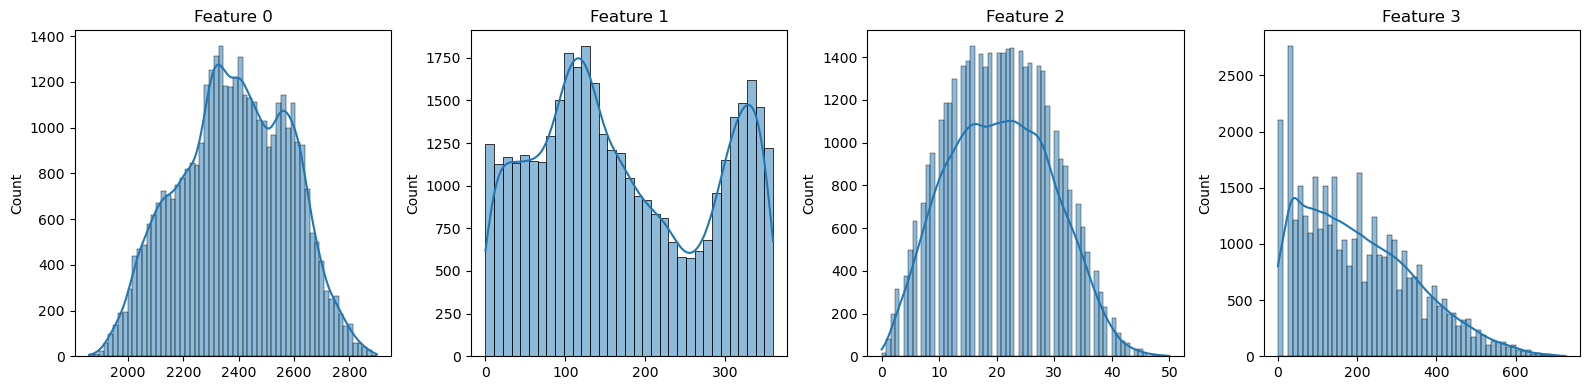

In [19]:
# Plot distribution of the first 4 features
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for i in range(4):
    sns.histplot(X[:, i], ax=axes[i], kde=True)
    axes[i].set_title(f'Feature {i}')
plt.tight_layout()
plt.show()

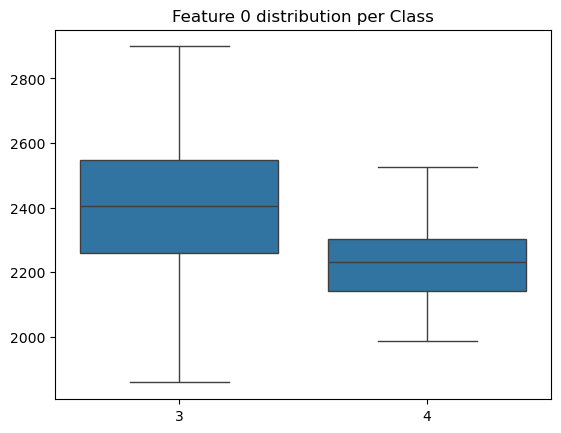

In [20]:
# Plot one feature against the target classes
sns.boxplot(x=y, y=X[:, 0]) # Change the index 0 to see other features
plt.title('Feature 0 distribution per Class')
plt.show()

In [15]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# 1. Define your models
# We use a pipeline to ensure scaling happens inside each fold
log_reg = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
rf = RandomForestClassifier(n_estimators=108, random_state=42)

# 2. Define the scoring metrics
scoring = ['accuracy', 'f1_macro', 'roc_auc_ovr']

# 3. Setup 5-fold cross-validation
# Stratified ensures each fold has the same class distribution as the original
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 4. Run evaluation
results_lr = cross_validate(log_reg, X, y, cv=cv, scoring=scoring)
results_rf = cross_validate(rf, X, y, cv=cv, scoring=scoring)

In [21]:
# Assuming you already have results_lr and results_rf from cross_validate
print("--- Logistic Regression ---")
print(f"Accuracy: {results_lr['test_accuracy'].mean():.4f}")
print(f"F1-Macro: {results_lr['test_f1_macro'].mean():.4f}")
print(f"ROC-AUC:  {results_lr['test_roc_auc_ovr'].mean():.4f}") # Add this line

print("\n--- Random Forest ---")
print(f"Accuracy: {results_rf['test_accuracy'].mean():.4f}")
print(f"F1-Macro: {results_rf['test_f1_macro'].mean():.4f}")
print(f"ROC-AUC:  {results_rf['test_roc_auc_ovr'].mean():.4f}") # Add this line

--- Logistic Regression ---
Accuracy: 0.9463
F1-Macro: 0.7569
ROC-AUC:  0.9476

--- Random Forest ---
Accuracy: 0.9860
F1-Macro: 0.9448
ROC-AUC:  0.9960


In [22]:
import pandas as pd
import numpy as np

# 1. Fit models on the full dataset to get final importances
# Note: Since we used a pipeline with scaling for LR, we access the regressor
log_reg.fit(X, y)
rf.fit(X, y)

# 2. Get LR Coefficients (using absolute value for importance)
lr_importances = np.abs(log_reg.named_steps['logisticregression'].coef_[0])

# 3. Get RF Importances
rf_importances = rf.feature_importances_

# 4. Create a DataFrame for ranking
feature_ranking = pd.DataFrame({
    'Feature_Index': range(X.shape[1]),
    'LR_Importance': lr_importances,
    'RF_Importance': rf_importances
})

# Normalize the scores so they are comparable on the same scale (0 to 1)
feature_ranking['LR_Norm'] = feature_ranking['LR_Importance'] / feature_ranking['LR_Importance'].sum()
feature_ranking['RF_Norm'] = feature_ranking['RF_Importance'] / feature_ranking['RF_Importance'].sum()

# Sort by Random Forest importance
ranked_features = feature_ranking.sort_values(by='RF_Importance', ascending=False)

print(ranked_features[['Feature_Index', 'LR_Norm', 'RF_Norm']].head(10))

    Feature_Index   LR_Norm   RF_Norm
0               0  0.083803  0.141503
3               3  0.056048  0.134944
5               5  0.082606  0.105651
9               9  0.060471  0.096101
4               4  0.035961  0.090941
6               6  0.055398  0.061733
16             16  0.017145  0.061184
1               1  0.003206  0.054771
8               8  0.046992  0.045103
7               7  0.059193  0.042622


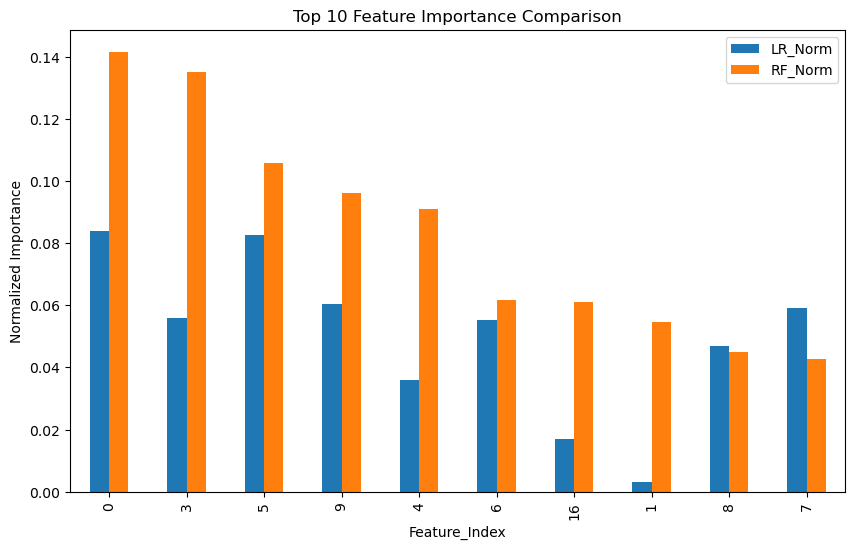

In [23]:
# Plot top 10 features
top_10 = ranked_features.head(10)
top_10.set_index('Feature_Index')[['LR_Norm', 'RF_Norm']].plot(kind='bar', figsize=(10, 6))
plt.title('Top 10 Feature Importance Comparison')
plt.ylabel('Normalized Importance')
plt.show()

In [ ]:
import shap

# 1. Create the Explainers
# TreeExplainer is lightning fast for Random Forest
explainer_rf = shap.TreeExplainer(rf)
shap_values_rf = explainer_rf.shap_values(X)

# KernelExplainer is slower, so we use a subset (background) to speed it up
# We use the mean of the training data as the reference point
background = shap.kmeans(X, 10) 
explainer_lr = shap.KernelExplainer(log_reg.predict_proba, background)
shap_values_lr = explainer_lr.shap_values(X[:100]) # Explaining 100 samples to keep it snappy

In [ ]:
# Summary plot for Random Forest
print("Random Forest SHAP Summary:")
shap.summary_plot(shap_values_rf, X, plot_type="bar")

# Summary plot for Logistic Regression
# Note: For multi-class, shap_values_lr is a list, so we plot for a specific class (e.g., class 0)
print("Logistic Regression SHAP Summary (Class 0):")
shap.summary_plot(shap_values_lr[0], X[:100])